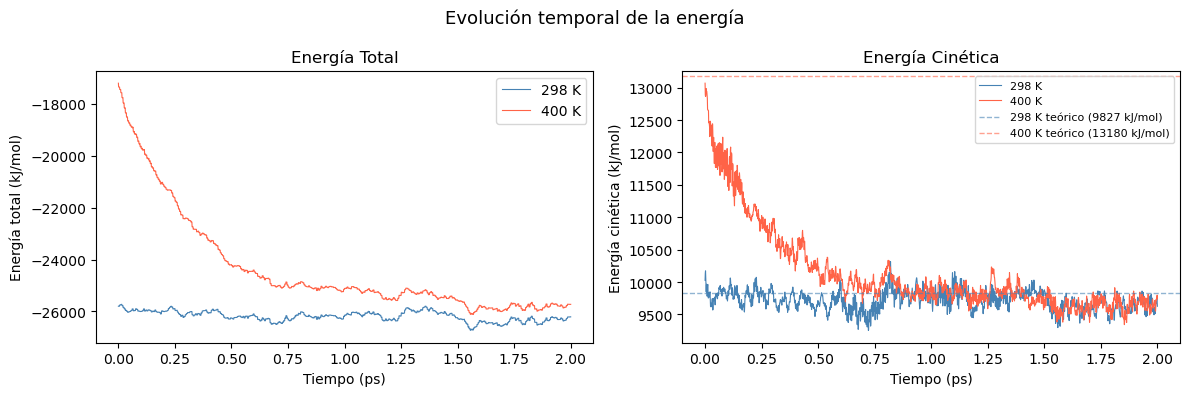

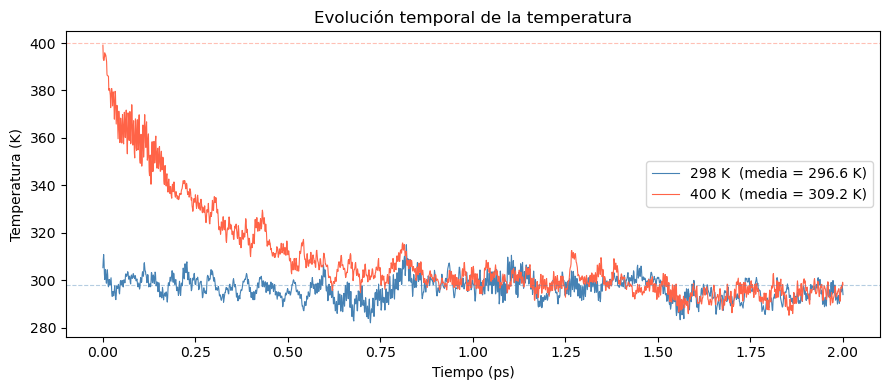

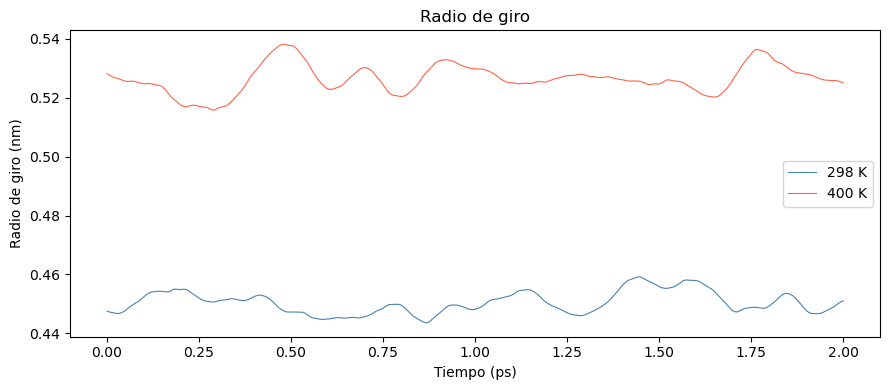

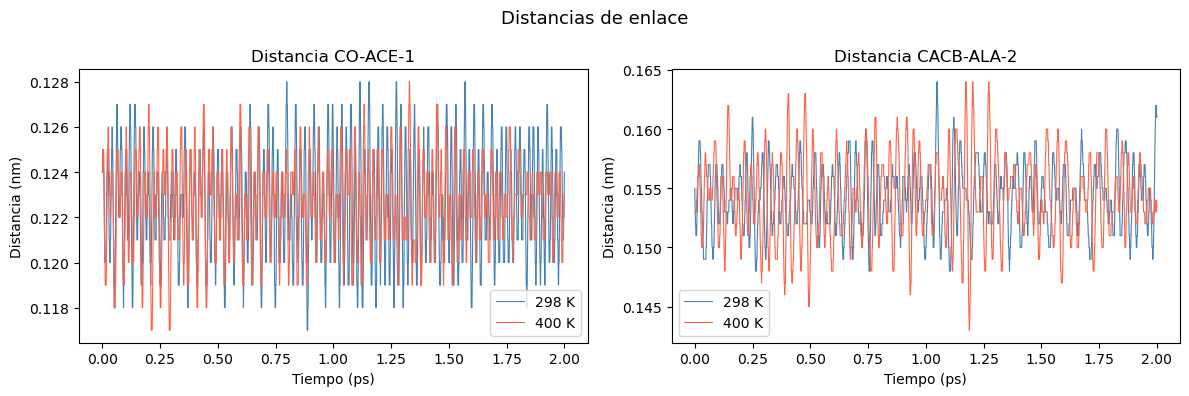

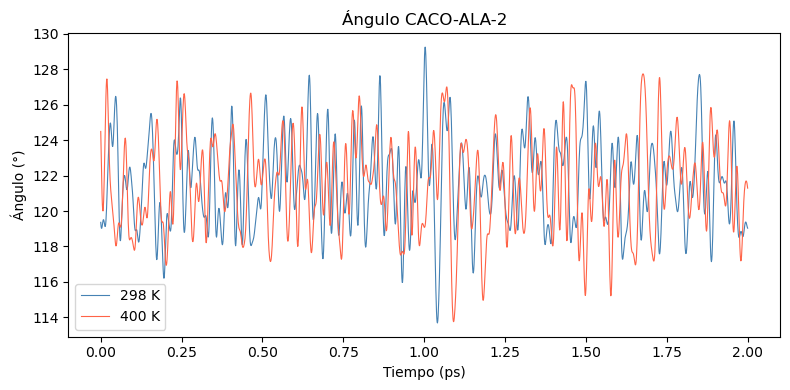

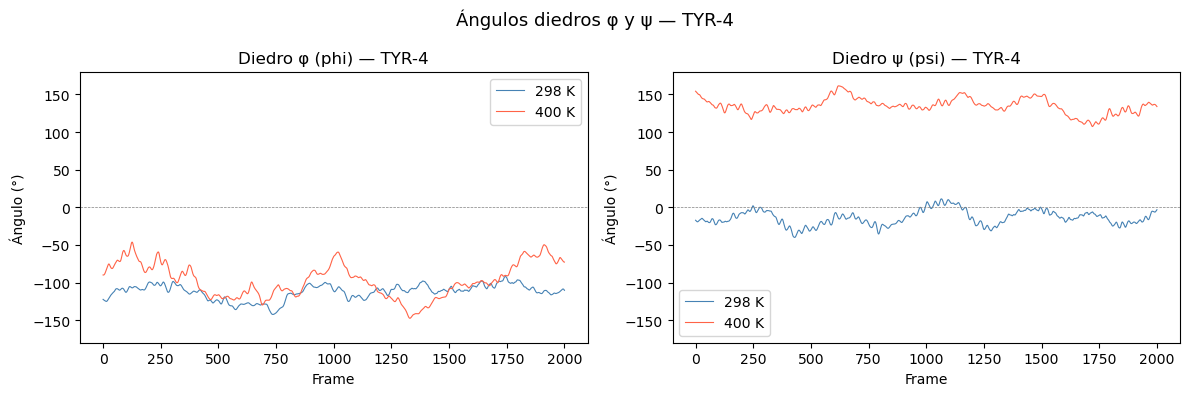

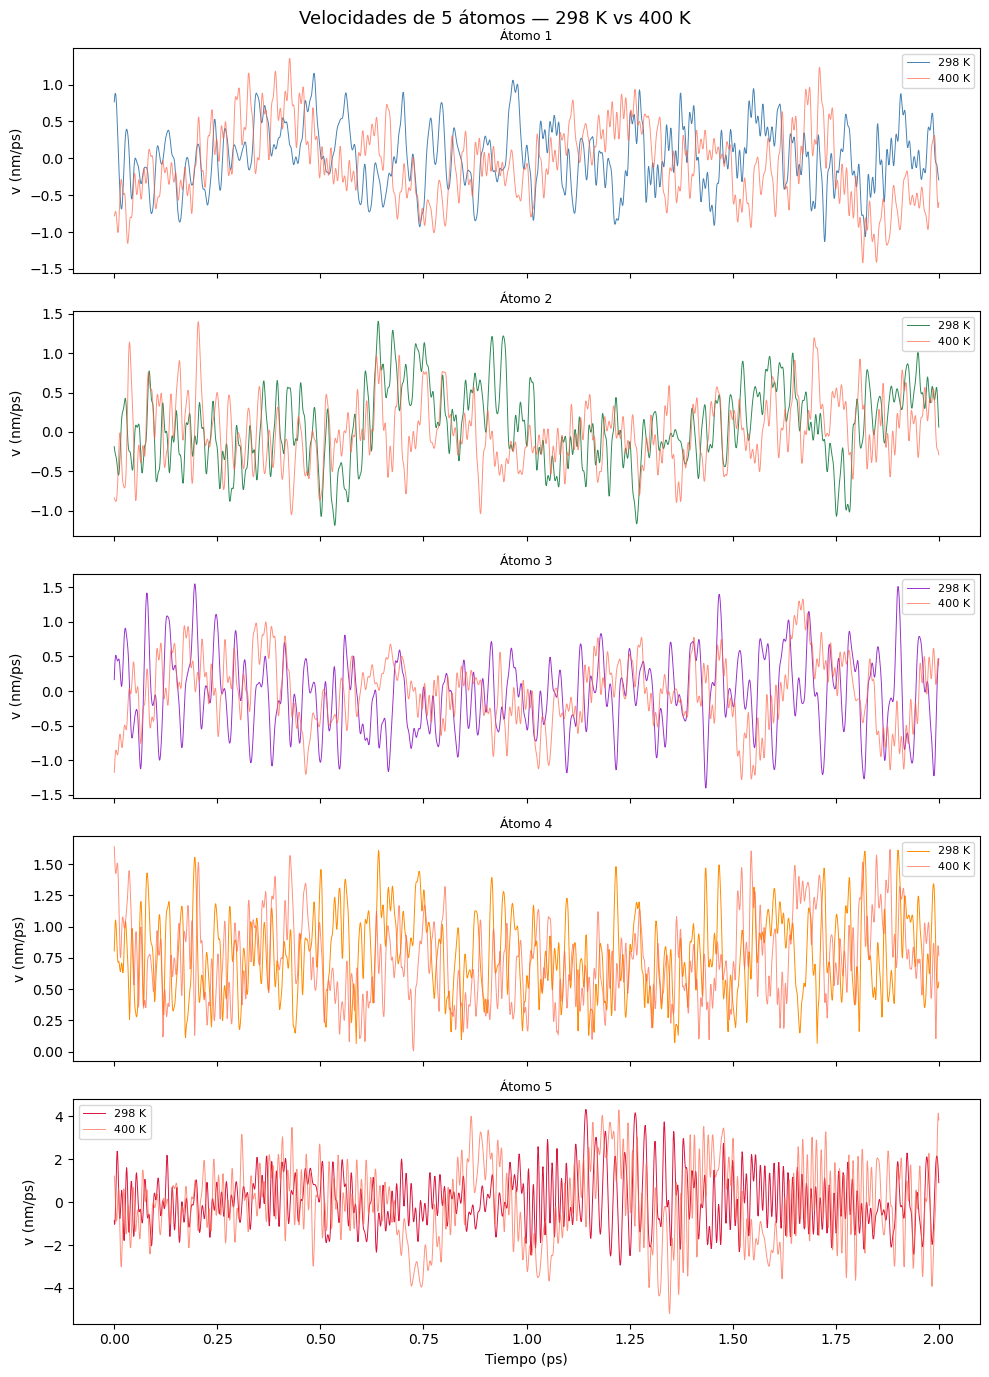

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def load_xvg(filename):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            if line.startswith('#') or line.startswith('@'):
                continue
            vals = line.split()
            if len(vals) >= 2:
                try:
                    data.append([float(v) for v in vals])  # ← ignora líneas con texto
                except ValueError:
                    continue   # ← salta líneas como "ALA-2"
    return np.array(data, dtype=float)

# Rutas
R298 = "./4-analisis/"
R400 = "./4-analisis400/"

# 1. ENERGÍA TOTAL Y CINÉTICA
etot_298 = load_xvg(R298 + "energytot.xvg")
etot_400 = load_xvg(R400 + "energytot.xvg")
ekin_298 = load_xvg(R298 + "energy.xvg")
ekin_400 = load_xvg(R400 + "energy.xvg")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Evolución temporal de la energía", fontsize=13)

axes[0].plot(etot_298[:, 0], etot_298[:, 1], color="steelblue", lw=0.8, label="298 K")
axes[0].plot(etot_400[:, 0], etot_400[:, 1], color="tomato",    lw=0.8, label="400 K")
axes[0].set_xlabel("Tiempo (ps)")
axes[0].set_ylabel("Energía total (kJ/mol)")
axes[0].set_title("Energía Total")
axes[0].legend()

axes[1].plot(ekin_298[:, 0], ekin_298[:, 1], color="steelblue", lw=0.8, label="298 K")
axes[1].plot(ekin_400[:, 0], ekin_400[:, 1], color="tomato",    lw=0.8, label="400 K")
axes[1].set_xlabel("Tiempo (ps)")
axes[1].set_ylabel("Energía cinética (kJ/mol)")
axes[1].set_title("Energía Cinética")

# Líneas teóricas del teorema de equipartición
# E_kin = 3/2 * N * k_B * T  →  para 2644 átomos:
axes[1].axhline(9827, color="steelblue", lw=1.0, linestyle="--",
                alpha=0.6, label="298 K teórico (9827 kJ/mol)")
axes[1].axhline(13180, color="tomato",   lw=1.0, linestyle="--",
                alpha=0.6, label="400 K teórico (13180 kJ/mol)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("energia.png", dpi=150, bbox_inches="tight")
plt.show()




# 2. TEMPERATURA

temp_298 = load_xvg(R298 + "temp.xvg")
temp_400 = load_xvg(R400 + "temp.xvg")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(temp_298[:, 0], temp_298[:, 1], color="steelblue", lw=0.8,
        label=f"298 K  (media = {np.mean(temp_298[:,1]):.1f} K)")
ax.plot(temp_400[:, 0], temp_400[:, 1], color="tomato",    lw=0.8,
        label=f"400 K  (media = {np.mean(temp_400[:,1]):.1f} K)")
ax.axhline(298, color="steelblue", linestyle="--", lw=0.8, alpha=0.4)
ax.axhline(400, color="tomato",    linestyle="--", lw=0.8, alpha=0.4)
ax.set_xlabel("Tiempo (ps)")
ax.set_ylabel("Temperatura (K)")
ax.set_title("Evolución temporal de la temperatura")
ax.legend()
plt.tight_layout()
plt.savefig("temperatura.png", dpi=150, bbox_inches="tight")
plt.show()


# 3. RADIO DE GIRO

gyr_298 = load_xvg(R298 + "gyrate.xvg")
gyr_400 = load_xvg(R400 + "gyrate.xvg")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gyr_298[:, 0], gyr_298[:, 1], color="steelblue", lw=0.8, label="298 K")
ax.plot(gyr_400[:, 0], gyr_400[:, 1], color="tomato",    lw=0.8, label="400 K")
ax.set_xlabel("Tiempo (ps)")
ax.set_ylabel("Radio de giro (nm)")
ax.set_title("Radio de giro")
ax.legend()
plt.tight_layout()
plt.savefig("radio_giro.png", dpi=150, bbox_inches="tight")
plt.show()


# 4. DISTANCIAS DE ENLACE

dist_298 = load_xvg(R298 + "angdist.xvg")
dist_400 = load_xvg(R400 + "angdist.xvg")

etiq_dist = ["CO-ACE-1", "CACB-ALA-2"]   

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distancias de enlace", fontsize=13)

for i, etiq in enumerate(etiq_dist):
    axes[i].plot(dist_298[:, 0], dist_298[:, i+1], color="steelblue", lw=0.8, label="298 K")
    axes[i].plot(dist_400[:, 0], dist_400[:, i+1], color="tomato",    lw=0.8, label="400 K")
    axes[i].set_xlabel("Tiempo (ps)")
    axes[i].set_ylabel("Distancia (nm)")
    axes[i].set_title(f"Distancia {etiq}")
    axes[i].legend()

plt.tight_layout()
plt.savefig("distancias.png", dpi=150, bbox_inches="tight")
plt.show()


# 5. ÁNGULOS
ang_298 = load_xvg(R298 + "angaver.xvg")
ang_400 = load_xvg(R400 + "angaver.xvg")

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(ang_298[:, 0], ang_298[:, 1], color="steelblue", lw=0.8, label="298 K")
ax.plot(ang_400[:, 0], ang_400[:, 1], color="tomato",    lw=0.8, label="400 K")
ax.set_xlabel("Tiempo (ps)")
ax.set_ylabel("Ángulo (°)")
ax.set_title("Ángulo CACO-ALA-2")
ax.legend()

plt.tight_layout()
plt.savefig("angulos.png", dpi=150, bbox_inches="tight")
plt.show()


# 6. ÁNGULOS DIEDROS φ y ψ

dih_298 = np.loadtxt(R298 + "TYR-4.dat")
dih_400 = np.loadtxt(R400 + "TYR-4.dat")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Ángulos diedros φ y ψ — TYR-4", fontsize=13)

frames_298 = np.arange(len(dih_298))
frames_400 = np.arange(len(dih_400))

axes[0].plot(frames_298, dih_298[:, 1], color="steelblue", lw=0.8, label="298 K")
axes[0].plot(frames_400, dih_400[:, 1], color="tomato",    lw=0.8, label="400 K")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Ángulo (°)")
axes[0].set_title("Diedro φ (phi) — TYR-4")
axes[0].set_ylim(-180, 180)
axes[0].axhline(0, color="gray", lw=0.5, linestyle="--")
axes[0].legend()

axes[1].plot(frames_298, dih_298[:, 2], color="steelblue", lw=0.8, label="298 K")
axes[1].plot(frames_400, dih_400[:, 2], color="tomato",    lw=0.8, label="400 K")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Ángulo (°)")
axes[1].set_title("Diedro ψ (psi) — TYR-4")
axes[1].set_ylim(-180, 180)
axes[1].axhline(0, color="gray", lw=0.5, linestyle="--")
axes[1].legend()

plt.tight_layout()
plt.savefig("diedros.png", dpi=150, bbox_inches="tight")
plt.show()


# 7. VELOCIDADES DE 5 ÁTOMOS

vel_298 = load_xvg(R298 + "veloc.xvg")
vel_400 = load_xvg(R400 + "veloc.xvg")


atomos  = ["Átomo 1", "Átomo 2", "Átomo 3", "Átomo 4", "Átomo 5"]
colores = ["steelblue", "seagreen", "darkorchid", "darkorange", "crimson"]

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)
fig.suptitle("Velocidades de 5 átomos — 298 K vs 400 K", fontsize=13)

for i, (atomo, col) in enumerate(zip(atomos, colores)):
    axes[i].plot(vel_298[:, 0], vel_298[:, i+1], color=col,      lw=0.7, label="298 K")
    axes[i].plot(vel_400[:, 0], vel_400[:, i+1], color="tomato",  lw=0.7, label="400 K", alpha=0.7)
    axes[i].set_ylabel("v (nm/ps)")
    axes[i].set_title(atomo, fontsize=9)
    axes[i].legend(fontsize=8)

axes[-1].set_xlabel("Tiempo (ps)")
plt.tight_layout()
plt.savefig("velocidades.png", dpi=150, bbox_inches="tight")
plt.show()



In [7]:
temp_298 = load_xvg("4-analisis/temp.xvg")
temp_400 = load_xvg("4-analisis400/temp.xvg")
print(f"298K: {len(temp_298)} frames, último tiempo: {temp_298[-1,0]:.2f} ps")
print(f"400K: {len(temp_400)} frames, último tiempo: {temp_400[-1,0]:.2f} ps")
print(f"298K primer valor: {temp_298[0,1]:.1f} K")
print(f"400K primer valor: {temp_400[0,1]:.1f} K")

298K: 2001 frames, último tiempo: 2.00 ps
400K: 2001 frames, último tiempo: 2.00 ps
298K primer valor: 305.3 K
400K primer valor: 399.1 K
